In [1]:
import sys
sys.path.append("..")  # jotta src/features.py löytyy notebookista

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.features import add_group_a_features

# Lataa setupit
setups = pd.read_parquet("../data/processed/setups.parquet")
print(f"Ladattu {len(setups)} setupia")

Ladattu 8281 setupia


In [2]:
# Lisää Ryhmä A:n piirteet
df = add_group_a_features(setups)

# Katsotaan uudet sarakkeet
new_cols = ["entry_position_in_box", "entry_outside_box", "hour_sin", "hour_cos"]
print("Uudet sarakkeet:")
df[new_cols].describe()

Uudet sarakkeet:


,entry_position_in_box,entry_outside_box,hour_sin,hour_cos
count,8281.000000,8281.000000,8281.000000,8281.000000
mean,0.045517,0.459486,0.036085,0.206675
std,1.379162,0.498386,0.634920,0.743623
min,-3.000000,0.000000,-1.000000,-1.000000
25%,-0.881449,0.000000,-0.500000,-0.500000
50%,0.039080,0.000000,0.000000,0.500000
75%,0.971205,1.000000,0.500000,0.965926
max,3.000000,1.000000,1.000000,1.000000


In [3]:
print("NaN-arvot uusissa sarakkeissa:")
print(df[new_cols].isna().sum())

NaN-arvot uusissa sarakkeissa:
entry_position_in_box    0
entry_outside_box        0
hour_sin                 0
hour_cos                 0
dtype: int64


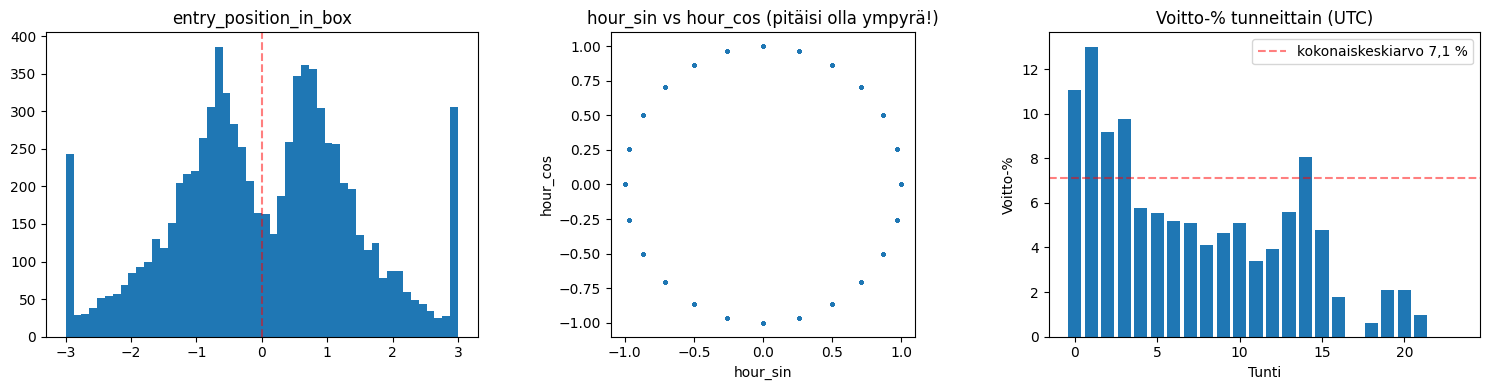

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["entry_position_in_box"].dropna(), bins=50)
axes[0].set_title("entry_position_in_box")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

axes[1].scatter(df["hour_sin"], df["hour_cos"], alpha=0.05, s=5)
axes[1].set_title("hour_sin vs hour_cos (pitäisi olla ympyrä!)")
axes[1].set_xlabel("hour_sin")
axes[1].set_ylabel("hour_cos")
axes[1].set_aspect("equal")

# Tunti vs voitto-% (vain labeled setupit)
labeled = df.dropna(subset=["label"]).copy()
labeled["hour"] = labeled["entry_time"].dt.hour
hourly_winrate = labeled.groupby("hour")["label"].agg(["mean", "count"])
axes[2].bar(hourly_winrate.index, hourly_winrate["mean"] * 100)
axes[2].set_title("Voitto-% tunneittain (UTC)")
axes[2].set_xlabel("Tunti")
axes[2].set_ylabel("Voitto-%")
axes[2].axhline(7.1, color="red", linestyle="--", alpha=0.5, label="kokonaiskeskiarvo 7,1 %")
axes[2].legend()

plt.tight_layout()
plt.show()

In [5]:
# Kuinka monta "epätavallista" entry_position_in_box -arvoa on?
extreme = df["entry_position_in_box"].abs() > 2
print(f"Setupeja joissa |entry_position_in_box| > 2: {extreme.sum()} ({extreme.mean()*100:.1f} %)")

extreme5 = df["entry_position_in_box"].abs() > 5
print(f"Setupeja joissa |entry_position_in_box| > 5: {extreme5.sum()} ({extreme5.mean()*100:.1f} %)")

# Katsotaan muutama ääriesimerkki
print("\nÄäripäät:")
print(df.nlargest(3, "entry_position_in_box")[["symbol", "date", "direction", "box_high", "box_low", "entry_price", "entry_position_in_box"]])
print()
print(df.nsmallest(3, "entry_position_in_box")[["symbol", "date", "direction", "box_high", "box_low", "entry_price", "entry_position_in_box"]])

Setupeja joissa |entry_position_in_box| > 2: 1252 (15.1 %)
Setupeja joissa |entry_position_in_box| > 5: 0 (0.0 %)

Ääripäät:
     symbol                      date direction  box_high  box_low  \
21  ETHUSDT 2024-01-08 00:00:00+00:00     short   2258.01  2203.46   
22  ETHUSDT 2024-01-08 00:00:00+00:00     short   2258.01  2203.46   
31  ETHUSDT 2024-01-10 00:00:00+00:00     short   2371.72  2226.78   

    entry_price  entry_position_in_box  
21      2328.72                    3.0  
22      2352.96                    3.0  
31      2534.64                    3.0  

    symbol                      date direction  box_high  box_low  \
3  ETHUSDT 2024-01-03 00:00:00+00:00      long    2431.3   2341.0   
4  ETHUSDT 2024-01-03 00:00:00+00:00      long    2431.3   2341.0   
5  ETHUSDT 2024-01-03 00:00:00+00:00      long    2431.3   2341.0   

   entry_price  entry_position_in_box  
3      2221.27                   -3.0  
4      2202.54                   -3.0  
5      2207.42                  

In [6]:
# Kuinka usein boxi on rikki sisäänmenohetkellä?
print(f"entry_outside_box = 1: {df['entry_outside_box'].sum()} setupia ({df['entry_outside_box'].mean()*100:.1f} %)")

# Onko tällä piirteellä yksinään ennustearvoa?
labeled = df.dropna(subset=["label"])
print("\nVoitto-% lipun mukaan (vain labeled setupit):")
print(labeled.groupby("entry_outside_box")["label"].agg(["mean", "count"]))

entry_outside_box = 1: 3805 setupia (45.9 %)

Voitto-% lipun mukaan (vain labeled setupit):
                       mean  count
entry_outside_box                 
0                  0.098185   3911
1                  0.031136   2730


In [7]:
# Yhdistetään säännöt: ensimmäinen setup per päivä JA boxi ehjä
combined = labeled[
    (labeled["setup_index_in_day"] == 1) &
    (labeled["entry_outside_box"] == 0)
]
print(f"Ensimmäinen setup + boxi ehjä: n={len(combined)}, voitto-% = {combined['label'].mean()*100:.1f} %")

# Verrokit:
first_only = labeled[labeled["setup_index_in_day"] == 1]
print(f"Vain ensimmäinen setup:        n={len(first_only)}, voitto-% = {first_only['label'].mean()*100:.1f} %")

inside_only = labeled[labeled["entry_outside_box"] == 0]
print(f"Vain boxi ehjä:                n={len(inside_only)}, voitto-% = {inside_only['label'].mean()*100:.1f} %")

# Ja vielä expected value (R/R huomioiden)
# Voitto = label * R/R, häviö = -1
combined_ev = (combined["label"] * combined["risk_reward_ratio"] - (1 - combined["label"])).mean()
print(f"\nYhdistetyn säännön Expected Value per kauppa (R-yksiköissä): {combined_ev:.3f}")

Ensimmäinen setup + boxi ehjä: n=1508, voitto-% = 11.3 %
Vain ensimmäinen setup:        n=1610, voitto-% = 11.0 %
Vain boxi ehjä:                n=3911, voitto-% = 9.8 %

Yhdistetyn säännön Expected Value per kauppa (R-yksiköissä): -0.293


In [8]:
# Mitkä ovat R/R-tunnusluvut tässä alaryhmässä?
print("Yhdistetty sääntö (n=1508):")
print(f"  R/R mediaani: {combined['risk_reward_ratio'].median():.2f}")
print(f"  R/R keskiarvo: {combined['risk_reward_ratio'].mean():.2f}")
print(f"  Voitto-%:       {combined['label'].mean()*100:.1f} %")

# Erottele voittajat ja häviäjät
winners = combined[combined["label"] == 1]
losers = combined[combined["label"] == 0]
print(f"\n  Voittavien R/R mediaani: {winners['risk_reward_ratio'].median():.2f}")
print(f"  Häviävien R/R mediaani:  {losers['risk_reward_ratio'].median():.2f}")

# Vertailu: koko aineisto
print("\nKoko labeled aineisto:")
all_winners = labeled[labeled["label"] == 1]
all_losers = labeled[labeled["label"] == 0]
print(f"  Voittavien R/R mediaani: {all_winners['risk_reward_ratio'].median():.2f}")
print(f"  Häviävien R/R mediaani:  {all_losers['risk_reward_ratio'].median():.2f}")

Yhdistetty sääntö (n=1508):
  R/R mediaani: 6.52
  R/R keskiarvo: 7.47
  Voitto-%:       11.3 %

  Voittavien R/R mediaani: 4.76
  Häviävien R/R mediaani:  6.84

Koko labeled aineisto:
  Voittavien R/R mediaani: 5.10
  Häviävien R/R mediaani:  8.39


In [9]:
# Voitto-% R/R-kvintiileittäin
labeled_copy = labeled.copy()
labeled_copy["rr_quintile"] = pd.qcut(labeled_copy["risk_reward_ratio"], q=5, labels=["Q1 (matalin)", "Q2", "Q3", "Q4", "Q5 (korkein)"])

print("Voitto-% R/R-kvintiileittäin:")
print(labeled_copy.groupby("rr_quintile", observed=True).agg(
    n=("label", "count"),
    voitto_pct=("label", lambda x: x.mean() * 100),
    rr_keskiarvo=("risk_reward_ratio", "mean"),
    ev=("label", lambda x: x.mean() * labeled_copy.loc[x.index, "risk_reward_ratio"].mean() - (1 - x.mean()))
).round(2))

Voitto-% R/R-kvintiileittäin:
                 n  voitto_pct  rr_keskiarvo    ev
rr_quintile                                       
Q1 (matalin)  1329       17.98          3.82 -0.13
Q2            1328        8.51          6.13 -0.39
Q3            1328        4.89          8.15 -0.55
Q4            1328        2.56         10.78 -0.70
Q5 (korkein)  1328        1.36         16.84 -0.76


## Ryhmä A: Yhteenveto löydöistä

| Piirre | Suunta | Vahvuus |
|---|---|---|
| setup_index_in_day | Pienempi = parempi (11 % → 0 %) | Vahva |
| entry_outside_box | 0 = parempi (9,8 % vs. 3,1 %) | Vahva |
| risk_reward_ratio | **Matalampi = parempi** (18 % → 1,4 %) | Erittäin vahva, vasta-intuitiivinen |
| hour_of_day | Tunnit 0–3 ja 14 parhaita | Kohtalainen |

**Tärkein johtopäätös:** EV on negatiivinen kaikissa R/R-kvintiileissä — naiivit sääntöpohjaiset filtterit eivät tee strategiasta kannattavaa. ML:n tehtävä on löytää epälineaariset yhdistelmät, jotka muuttavat tämän.

In [10]:
# Lataa päivätason data molemmille pareille
daily_data = {
    "ETHUSDT": pd.read_parquet("../data/raw/ETHUSDT_1d.parquet"),
    "SOLUSDT": pd.read_parquet("../data/raw/SOLUSDT_1d.parquet"),
}

# Tarkista että data on järkevää
for symbol, d in daily_data.items():
    print(f"{symbol}: {len(d)} päivää, väli {d.index.min()} – {d.index.max()}")
    print(f"  Sarakkeet: {list(d.columns)}")

ETHUSDT: 859 päivää, väli 2024-01-01 00:00:00+00:00 – 2026-05-08 00:00:00+00:00
  Sarakkeet: ['open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'trades', 'taker_base_vol', 'taker_quote_vol']
SOLUSDT: 859 päivää, väli 2024-01-01 00:00:00+00:00 – 2026-05-08 00:00:00+00:00
  Sarakkeet: ['open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'trades', 'taker_base_vol', 'taker_quote_vol']


In [11]:
from src.features import add_group_b_features

# Lisää Ryhmä B:n piirteet (df:ssä on jo Ryhmä A:n piirteet)
df = add_group_b_features(df, daily_data)

new_cols_b = ["prev_day_range_pct", "box_size_vs_atr14d"]
print("Ryhmä B:n uudet sarakkeet:")
df[new_cols_b].describe()

Ryhmä B:n uudet sarakkeet:


,prev_day_range_pct,box_size_vs_atr14d
count,8281.000000,8182.000000
mean,6.630998,0.954554
std,3.718493,0.463691
min,0.846530,0.181512
25%,4.131954,0.638346
50%,5.817890,0.869999
75%,8.184917,1.162951
max,30.101349,4.071462


In [12]:
print("NaN-arvot Ryhmä B:n sarakkeissa:")
print(df[new_cols_b].isna().sum())
print()
print(f"Yhteensä rivejä: {len(df)}")

NaN-arvot Ryhmä B:n sarakkeissa:
prev_day_range_pct     0
box_size_vs_atr14d    99
dtype: int64

Yhteensä rivejä: 8281


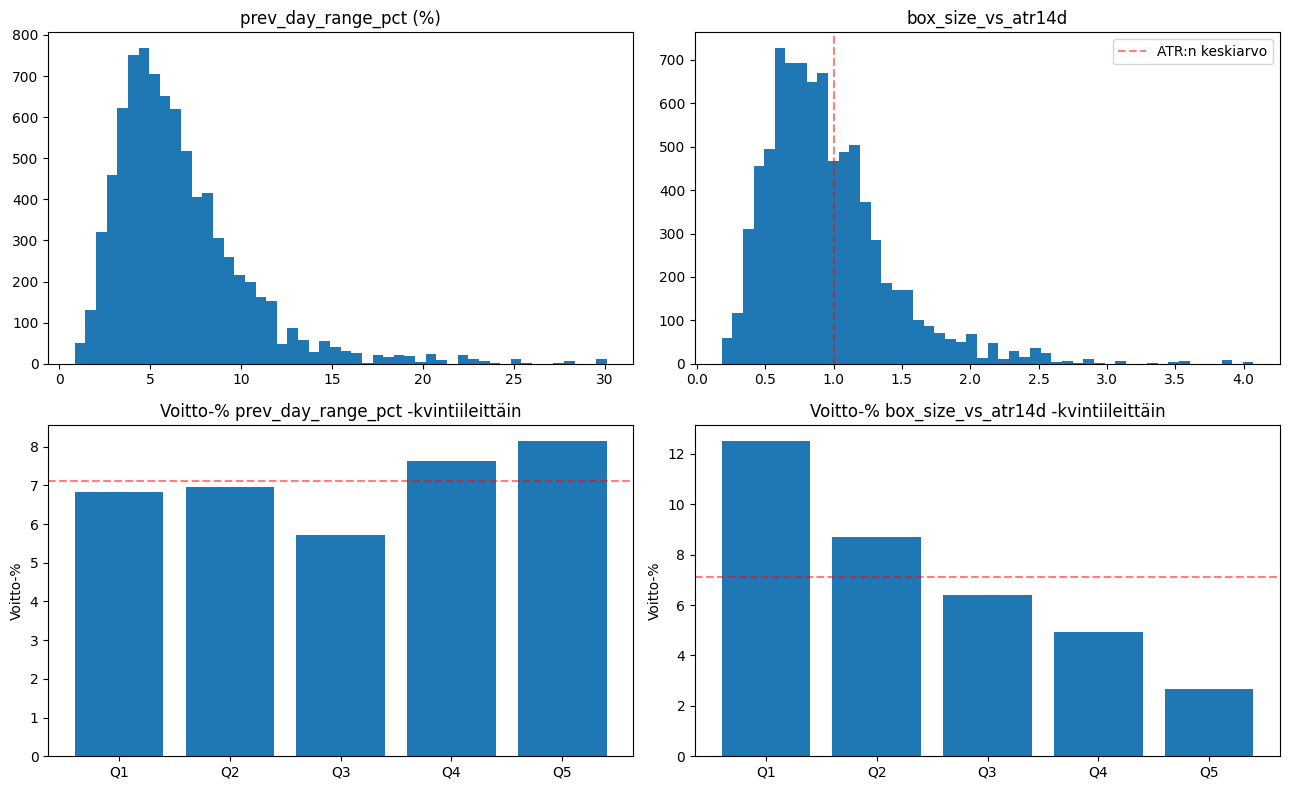


Voitto-% prev_day_range_pct -kvintiileittäin:
                   n  voitto_pct  range_keskiarvo
range_quintile                                   
Q1              1317        6.83             3.01
Q2              1310        6.95             4.57
Q3              1314        5.71             5.96
Q4              1313        7.62             7.72
Q5              1312        8.16            12.47

Voitto-% box_size_vs_atr14d -kvintiileittäin:
                 n  voitto_pct  atr_keskiarvo
atr_quintile                                 
Q1            1317       12.53           0.46
Q2            1312        8.69           0.67
Q3            1311        6.41           0.86
Q4            1313        4.95           1.08
Q5            1313        2.67           1.64


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(df["prev_day_range_pct"].dropna(), bins=50)
axes[0, 0].set_title("prev_day_range_pct (%)")

axes[0, 1].hist(df["box_size_vs_atr14d"].dropna(), bins=50)
axes[0, 1].set_title("box_size_vs_atr14d")
axes[0, 1].axvline(1.0, color="red", linestyle="--", alpha=0.5, label="ATR:n keskiarvo")
axes[0, 1].legend()

labeled = df.dropna(subset=["label", "prev_day_range_pct", "box_size_vs_atr14d"]).copy()

labeled["range_quintile"] = pd.qcut(labeled["prev_day_range_pct"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
range_winrate = labeled.groupby("range_quintile", observed=True)["label"].mean() * 100
axes[1, 0].bar(range_winrate.index.astype(str), range_winrate.values)
axes[1, 0].set_title("Voitto-% prev_day_range_pct -kvintiileittäin")
axes[1, 0].set_ylabel("Voitto-%")
axes[1, 0].axhline(7.1, color="red", linestyle="--", alpha=0.5)

labeled["atr_quintile"] = pd.qcut(labeled["box_size_vs_atr14d"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
atr_winrate = labeled.groupby("atr_quintile", observed=True)["label"].mean() * 100
axes[1, 1].bar(atr_winrate.index.astype(str), atr_winrate.values)
axes[1, 1].set_title("Voitto-% box_size_vs_atr14d -kvintiileittäin")
axes[1, 1].set_ylabel("Voitto-%")
axes[1, 1].axhline(7.1, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("\nVoitto-% prev_day_range_pct -kvintiileittäin:")
print(labeled.groupby("range_quintile", observed=True).agg(
    n=("label", "count"),
    voitto_pct=("label", lambda x: x.mean() * 100),
    range_keskiarvo=("prev_day_range_pct", "mean")
).round(2))

print("\nVoitto-% box_size_vs_atr14d -kvintiileittäin:")
print(labeled.groupby("atr_quintile", observed=True).agg(
    n=("label", "count"),
    voitto_pct=("label", lambda x: x.mean() * 100),
    atr_keskiarvo=("box_size_vs_atr14d", "mean")
).round(2))

In [14]:
# Korreloiko box_size_vs_atr14d risk_reward_ratio:n kanssa?
labeled[["box_size_vs_atr14d", "risk_reward_ratio"]].corr().round(3)

,box_size_vs_atr14d,risk_reward_ratio
box_size_vs_atr14d,1.000,0.478
risk_reward_ratio,0.478,1.000


In [15]:
# HISTORIA: tämä solu vertaili box_size_pct vs. box_size_vs_atr14d
# Päätös tehty Ryhmä B:n lopussa: box_size_pct poistettu features.py:stä,
# joten tätä analyysiä ei voi enää ajaa. Säilytetään dokumentaationa.
print("Solu ohitettu — box_size_pct poistettu Ryhmä B:n päätöksellä")

Solu ohitettu — box_size_pct poistettu Ryhmä B:n päätöksellä


# Ryhmä C: Multi-timeframe trendi (4h)

In [16]:
# Lataa 4h-data
import pandas as pd
df_4h_eth = pd.read_parquet('../data/raw/ETHUSDT_4h.parquet')
df_4h_sol = pd.read_parquet('../data/raw/SOLUSDT_4h.parquet')

print("ETHUSDT 4h:", df_4h_eth.shape, "indeksi:", df_4h_eth.index.name)
print("Sarakkeet:", df_4h_eth.columns.tolist())
df_4h_eth.head(2)

ETHUSDT 4h: (5149, 10) indeksi: open_time
Sarakkeet: ['open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'trades', 'taker_base_vol', 'taker_quote_vol']


,open,high,low,close,volume,close_time,quote_volume,trades,taker_base_vol,taker_quote_vol
open_time,,,,,,,,,,
2024-01-01 00:00:00+00:00,2281.87,2306.60,2271.00,2273.81,35739.3336,2024-01-01 03:59:59.999000+00:00,8.191288e+07,87164,17821.0674,4.084860e+07
2024-01-01 04:00:00+00:00,2273.80,2287.88,2265.24,2284.67,28107.5133,2024-01-01 07:59:59.999000+00:00,6.403174e+07,75452,14529.7001,3.310668e+07


In [17]:
setups_with_features = df.copy()
print("OK, sarakkeet:", setups_with_features.columns.tolist())
print("Setupeja:", len(setups_with_features))

OK, sarakkeet: ['setup_id', 'symbol', 'date', 'direction', 'setup_index_in_day', 'box_high', 'box_low', 'box_mid', 'entry_time', 'entry_price', 'stop_loss', 'take_profit', 'risk_reward_ratio', 'outcome_time', 'outcome', 'label', 'date_only', 'entry_outside_box', 'entry_position_in_box', 'hour_sin', 'hour_cos', 'prev_day_range_pct', 'box_size_vs_atr14d']
Setupeja: 8281


In [18]:
import importlib
import src.features
importlib.reload(src.features)
from src.features import add_group_c_features

In [19]:
# Erotellaan symboleittain
setups_eth = setups_with_features[setups_with_features['symbol'] == 'ETHUSDT'].copy()
setups_sol = setups_with_features[setups_with_features['symbol'] == 'SOLUSDT'].copy()

# Lisätään Ryhmä C:n piirteet
setups_eth_c = add_group_c_features(setups_eth, df_4h_eth)
setups_sol_c = add_group_c_features(setups_sol, df_4h_sol)

# Yhdistetään
setups_with_features = pd.concat([setups_eth_c, setups_sol_c], ignore_index=True)

print("Valmis. Setupien määrä:", len(setups_with_features))
print("Uudet sarakkeet:", [c for c in ['ema50_4h', 'ema200_4h', 'trend_4h', 'trend_aligned'] if c in setups_with_features.columns])

Valmis. Setupien määrä: 8281
Uudet sarakkeet: ['ema50_4h', 'ema200_4h', 'trend_4h', 'trend_aligned']


In [20]:
import os
print("Nykyinen työhakemisto:", os.getcwd())
print("Sisältö:", os.listdir('.'))

Nykyinen työhakemisto: /Users/sbanbe/Documents/projektit/boxmethod/notebooks
Sisältö: ['01_data_fetch.ipynb', '03_features.ipynb', '02_box_setups.ipynb']


In [21]:
print(setups_with_features.shape)
print(setups_with_features.columns.tolist())
print(setups_with_features['symbol'].value_counts())

(8281, 28)
['setup_id', 'symbol', 'date', 'direction', 'setup_index_in_day', 'box_high', 'box_low', 'box_mid', 'entry_time', 'entry_price', 'stop_loss', 'take_profit', 'risk_reward_ratio', 'outcome_time', 'outcome', 'label', 'date_only', 'entry_outside_box', 'entry_position_in_box', 'hour_sin', 'hour_cos', 'prev_day_range_pct', 'box_size_vs_atr14d', 'close_time', 'ema50_4h', 'ema200_4h', 'trend_4h', 'trend_aligned']
symbol
SOLUSDT    4265
ETHUSDT    4016
Name: count, dtype: int64


In [22]:
# Onko muuttuja olemassa kerneliin?
print('setups_with_features' in dir())
print('df' in dir())

True
True


In [23]:
# 1) NaN-tarkistus
print("NaN per sarake:")
print(setups_with_features[['ema50_4h', 'ema200_4h', 'trend_4h', 'trend_aligned']].isna().sum())

# 2) trend_4h jakauma — pitäisi olla suurin osa välillä -0.2 ... +0.2,
#    eli ±20 % poikkeama EMA200:sta on jo iso trendi
print("\ntrend_4h jakauma:")
print(setups_with_features['trend_4h'].describe())

# 3) trend_aligned jakauma — pitäisi olla suunnilleen 50/50 jos
#    setupeja muodostuu tasapuolisesti molemmissa trendeissä
print("\ntrend_aligned jakauma:")
print(setups_with_features['trend_aligned'].value_counts(normalize=True))

NaN per sarake:
ema50_4h         0
ema200_4h        0
trend_4h         0
trend_aligned    0
dtype: int64

trend_4h jakauma:
count    8281.000000
mean       -0.004275
std         0.076456
min        -0.200413
25%        -0.053195
50%        -0.008851
75%         0.042929
max         0.248807
Name: trend_4h, dtype: float64

trend_aligned jakauma:
trend_aligned
1    0.500423
0    0.499577
Name: proportion, dtype: float64


In [24]:
# A) trend_aligned -lippu: vaikuttaako voitto-%:iin?
print("=== Löytö: trend_aligned vs. voitto-% ===")
labeled = setups_with_features.dropna(subset=['label']).copy()
print(labeled.groupby('trend_aligned').agg(
    n=('label', 'count'),
    voitto_pct=('label', lambda x: x.mean() * 100)
))

# B) trend_4h kvintiileittäin (vain ei-NaN)
print("\n=== Löytö: trend_4h kvintiilit vs. voitto-% ===")
labeled_with_trend = labeled.dropna(subset=['trend_4h']).copy()
labeled_with_trend['trend_q'] = pd.qcut(labeled_with_trend['trend_4h'], 5, labels=False) + 1
print(labeled_with_trend.groupby('trend_q').agg(
    trend_keski=('trend_4h', 'mean'),
    n=('label', 'count'),
    voitto_pct=('label', lambda x: x.mean() * 100)
))

# C) Tarkennus: long ja short erikseen, koska trendin merkitys voi olla erilainen
print("\n=== Löytö: trend_aligned per direction ===")
print(labeled.groupby(['direction', 'trend_aligned']).agg(
    n=('label', 'count'),
    voitto_pct=('label', lambda x: x.mean() * 100)
))

=== Löytö: trend_aligned vs. voitto-% ===
                  n  voitto_pct
trend_aligned                  
0              3322    7.375075
1              3319    6.749021

=== Löytö: trend_4h kvintiilit vs. voitto-% ===
         trend_keski     n  voitto_pct
trend_q                               
1          -0.108286  1330    6.992481
2          -0.043885  1327    6.857573
3          -0.009388  1328    6.701807
4           0.030597  1328    7.530120
5           0.108530  1328    7.228916

=== Löytö: trend_aligned per direction ===
                            n  voitto_pct
direction trend_aligned                  
long      0              1824    7.565789
          1              1472    7.336957
short     0              1498    7.142857
          1              1847    6.280455


In [25]:
import os
files = os.listdir('../data/processed/')
print("Processed-kansiossa:", files)

Processed-kansiossa: ['setups.parquet']


In [26]:
# Mitä muuttujia on muistissa?
my_vars = [v for v in dir() if not v.startswith('_') and v not in ['In', 'Out', 'exit', 'quit', 'get_ipython']]
print("Muuttujat muistissa:")
for v in my_vars:
    val = eval(v)
    if hasattr(val, 'shape'):
        print(f"  {v}: DataFrame {val.shape}")
    elif hasattr(val, '__len__') and not isinstance(val, str):
        try:
            print(f"  {v}: {type(val).__name__}, pituus {len(val)}")
        except:
            print(f"  {v}: {type(val).__name__}")
    else:
        print(f"  {v}: {type(val).__name__}")

Muuttujat muistissa:
  add_group_a_features: function
  add_group_b_features: function
  add_group_c_features: function
  all_losers: DataFrame (6172, 21)
  all_winners: DataFrame (469, 21)
  atr_winrate: DataFrame (5,)
  axes: DataFrame (2, 2)
  combined: DataFrame (1508, 21)
  combined_ev: DataFrame ()
  d: DataFrame (859, 10)
  daily_data: dict, pituus 2
  df: DataFrame (8281, 23)
  df_4h_eth: DataFrame (5149, 10)
  df_4h_sol: DataFrame (5149, 10)
  extreme: DataFrame (8281,)
  extreme5: DataFrame (8281,)
  fig: Figure
  files: list, pituus 1
  first_only: DataFrame (1610, 21)
  hourly_winrate: DataFrame (24, 2)
  importlib: module
  inside_only: DataFrame (3911, 21)
  labeled: DataFrame (6641, 28)
  labeled_copy: DataFrame (6641, 22)
  labeled_with_trend: DataFrame (6641, 29)
  losers: DataFrame (1338, 21)
  new_cols: list, pituus 4
  new_cols_b: list, pituus 2
  np: DataFrame <function shape at 0x10d1cfc40>
  open: function
  os: module
  pd: module
  plt: module
  range_winrate: 

In [ ]:
# Välitallennus: setupit kaikkien tähän mennessä toteutettujen piirteiden kanssa
output_path = '../data/processed/setups_with_features.parquet'
setups_with_features.to_parquet(output_path, index=False)
print(f"Tallennettu: {output_path}")
print(f"Rivejä: {len(setups_with_features)}, sarakkeita: {len(setups_with_features.columns)}")